In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
import pyarrow.parquet as pq

pd.set_option("display.max_columns", 120)
DATA_DIR = "../data/"

train_tte = pd.read_csv(DATA_DIR + "train_tte.csv")
print("TTE:", train_tte.shape)
print(train_tte.head())

TTE: (23550, 3)
   vehicle_id  length_of_study_time_step  in_study_repair
0           0                      510.0                0
1           2                      281.8                0
2           3                      293.4                0
3           4                      210.0                0
4           5                      360.4                0


In [3]:
pf = pq.ParquetFile(DATA_DIR + "train_features.parquet")
print("Row groups:", pf.num_row_groups, "| columns:", len(pf.schema.names))

parts = []
for i in range(pf.num_row_groups):
    chunk = pf.read_row_group(i).to_pandas()
    parts.append(chunk.sort_values("time_step").groupby("vehicle_id").tail(1))
    del chunk

last_readout = pd.concat(parts).sort_values("time_step").groupby("vehicle_id").tail(1)
del parts
print("Last readouts:", last_readout.shape)      # expect ~23,550 rows

Row groups: 2 | columns: 214
Last readouts: (23550, 214)


Vehicles: 23550
Failures: 2272 | Censored: 21278
Median duration - failed:   208
Median duration - censored: 219


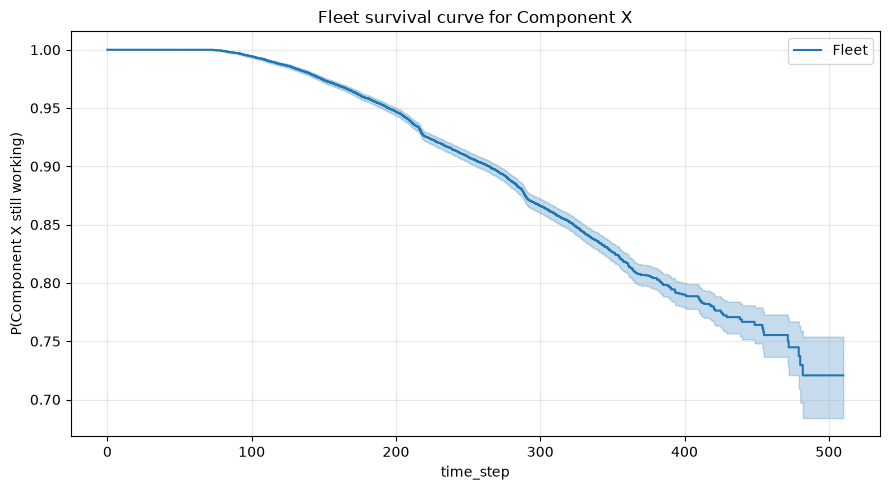

S(100) = 0.994
S(200) = 0.947
S(300) = 0.866
S(400) = 0.790
S(500) = 0.721
Median survival: inf


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

DATA_DIR = "../data/"
train_tte = pd.read_csv(DATA_DIR + "train_tte.csv")

surv = train_tte.rename(columns={
    "length_of_study_time_step": "duration",
    "in_study_repair": "event",
})

print("Vehicles:", len(surv))
print("Failures:", surv['event'].sum(), "| Censored:", (surv['event']==0).sum())
print(f"Median duration - failed:   {surv.loc[surv.event==1,'duration'].median():.0f}")
print(f"Median duration - censored: {surv.loc[surv.event==0,'duration'].median():.0f}")

kmf = KaplanMeierFitter()
kmf.fit(surv["duration"], surv["event"], label="Fleet")

fig, ax = plt.subplots(figsize=(9, 5))
kmf.plot_survival_function(ax=ax)
ax.set_xlabel("time_step"); ax.set_ylabel("P(Component X still working)")
ax.set_title("Fleet survival curve for Component X")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

for t in [100, 200, 300, 400, 500]:
    print(f"S({t}) = {float(kmf.predict(t)):.3f}")
print("Median survival:", kmf.median_survival_time_)

In [5]:
keep = (["vehicle_id", "time_step"] + counter_cols + rate_cols
        + [c for c in pf.schema.names if c.startswith("Spec_")])
df = pd.read_parquet(DATA_DIR + "train_features.parquet", columns=keep)
df = df.sort_values("time_step").groupby("vehicle_id").tail(1)

NameError: name 'counter_cols' is not defined

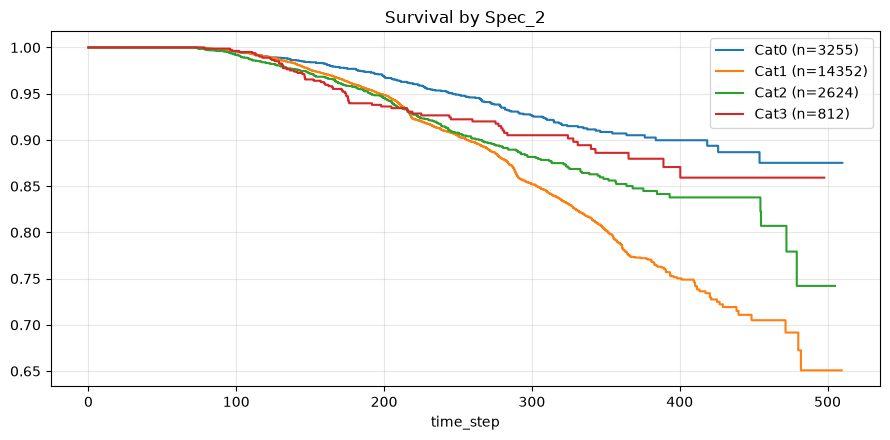

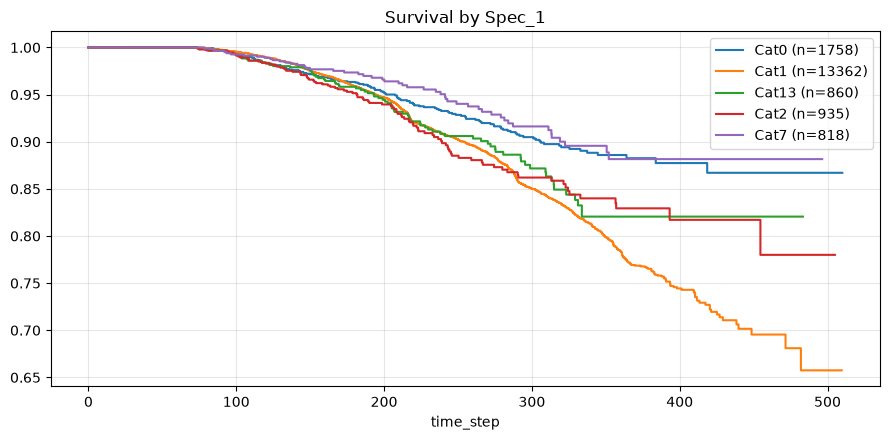

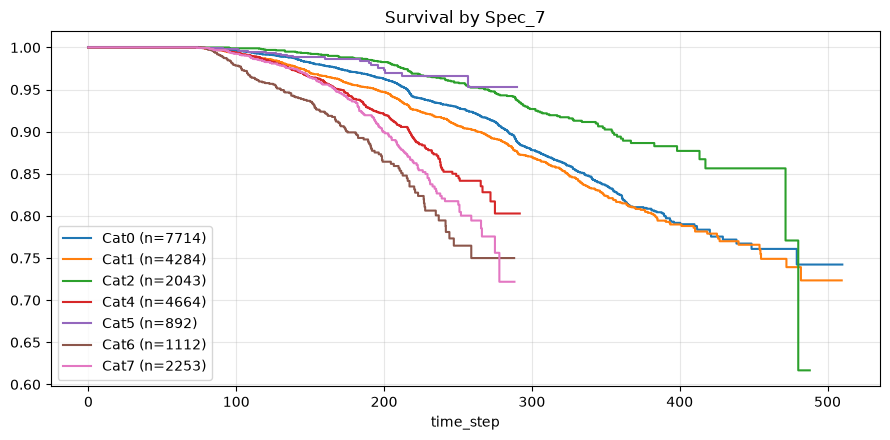

In [6]:
spec = pd.read_csv(DATA_DIR + "train_specifications.csv")
s = surv.merge(spec, on="vehicle_id")

for col in ["Spec_2", "Spec_1", "Spec_7"]:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for cat, grp in s.groupby(col):
        if len(grp) < 800:
            continue
        k = KaplanMeierFitter()
        k.fit(grp["duration"], grp["event"], label=f"{cat} (n={len(grp)})")
        k.plot_survival_function(ax=ax, ci_show=False)
    ax.set_title(f"Survival by {col}")
    ax.set_xlabel("time_step"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

In [7]:
# Fair comparison at a common horizon
for col in ["Spec_2", "Spec_1", "Spec_7"]:
    print(f"\n--- {col}: S(250) by category ---")
    for cat, grp in s.groupby(col):
        if len(grp) < 800: continue
        k = KaplanMeierFitter().fit(grp["duration"], grp["event"])
        print(f"  {cat:<8} n={len(grp):>6}  S(250)={float(k.predict(250)):.3f}")

# Are Spec_1 and Spec_2 redundant?
print("\nSpec_1 x Spec_2 crosstab:")
print(pd.crosstab(s["Spec_1"], s["Spec_2"]).loc[lambda d: d.sum(axis=1) > 500])


--- Spec_2: S(250) by category ---
  Cat0     n=  3255  S(250)=0.949
  Cat1     n= 14352  S(250)=0.904
  Cat2     n=  2624  S(250)=0.908
  Cat3     n=   812  S(250)=0.922

--- Spec_1: S(250) by category ---
  Cat0     n=  1758  S(250)=0.929
  Cat1     n= 13362  S(250)=0.902
  Cat13    n=   860  S(250)=0.906
  Cat2     n=   935  S(250)=0.885
  Cat7     n=   818  S(250)=0.940

--- Spec_7: S(250) by category ---
  Cat0     n=  7714  S(250)=0.928
  Cat1     n=  4284  S(250)=0.907
  Cat2     n=  2043  S(250)=0.958
  Cat4     n=  4664  S(250)=0.847
  Cat5     n=   892  S(250)=0.967
  Cat6     n=  1112  S(250)=0.765
  Cat7     n=  2253  S(250)=0.818

Spec_1 x Spec_2 crosstab:
Spec_2  Cat0   Cat1  Cat10  Cat11  Cat12  Cat13  Cat14  Cat15  Cat16  Cat17  \
Spec_1                                                                        
Cat0    1062     17     18      1      7     10      2      0      1      2   
Cat1      66  13016    253      0      0      0      4      0      0      0   
Cat10

In [8]:
from lifelines.statistics import multivariate_logrank_test

res = []
for col in [c for c in spec.columns if c != "vehicle_id"]:
    r = multivariate_logrank_test(s["duration"], s[col], s["event"])
    res.append({"spec": col, "statistic": round(r.test_statistic, 1),
                "n_categories": s[col].nunique()})
print(pd.DataFrame(res).sort_values("statistic", ascending=False).to_string(index=False))

  spec  statistic  n_categories
Spec_7      425.3             9
Spec_2      327.2            21
Spec_1      192.8            29
Spec_6      117.9            17
Spec_3       96.6             4
Spec_0       65.6             3
Spec_4       47.6             2
Spec_5        4.3             5


In [9]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(DATA_DIR + "train_features.parquet")
counter_cols = ["171_0","666_0","427_0","837_0","309_0","835_0","370_0","100_0"]
rate_cols    = [f"{c}_rate" for c in counter_cols]

# Read only what we need - avoids the earlier MemoryError
keep = ["vehicle_id", "time_step"] + counter_cols + rate_cols
feat = pd.read_parquet(DATA_DIR + "train_features.parquet", columns=keep)
feat = feat.sort_values("time_step").groupby("vehicle_id").tail(1)
print("Vehicle-level features:", feat.shape)

cox_df = (surv.merge(feat, on="vehicle_id")
              .merge(spec[["vehicle_id", "Spec_7", "Spec_2"]], on="vehicle_id"))

# One-hot the two specs that matter; drop Spec_1 (97% redundant with Spec_2)
cox_df = pd.get_dummies(cox_df, columns=["Spec_7", "Spec_2"], drop_first=True)
cox_df = cox_df.drop(columns=["vehicle_id", "time_step"])

# Cox needs scaled, finite inputs
num = counter_cols + rate_cols
cox_df[num] = cox_df[num].replace([np.inf,-np.inf], np.nan).fillna(0)
cox_df[num] = (cox_df[num] - cox_df[num].mean()) / cox_df[num].std().replace(0, 1)

print("Cox table:", cox_df.shape)

Vehicle-level features: (23550, 18)
Cox table: (23550, 46)


In [10]:
cph = CoxPHFitter(penalizer=0.1)          # ridge penalty for stability with collinear features
cph.fit(cox_df, duration_col="duration", event_col="event")

print("Concordance index:", round(cph.concordance_index_, 4))
print("\nStrongest effects (hazard ratios):")
summary = cph.summary[["exp(coef)", "p"]].copy()
summary["effect"] = np.abs(np.log(summary["exp(coef)"]))
print(summary.sort_values("effect", ascending=False).head(15).round(4).to_string())

Concordance index: 0.8238

Strongest effects (hazard ratios):
              exp(coef)       p  effect
covariate                              
Spec_2_Cat19     3.5105  0.2346  1.2558
Spec_2_Cat11     0.4870  0.2192  0.7194
Spec_2_Cat20     1.9977  0.4399  0.6920
Spec_2_Cat14     1.8229  0.0195  0.6004
Spec_2_Cat15     1.7730  0.2727  0.5727
Spec_2_Cat4      0.5857  0.2594  0.5350
Spec_2_Cat5      1.6890  0.0000  0.5241
Spec_2_Cat16     1.6851  0.4119  0.5218
Spec_7_Cat3      0.6326  0.0007  0.4579
Spec_2_Cat12     0.6376  0.0107  0.4500
Spec_2_Cat6      1.5606  0.0010  0.4450
Spec_2_Cat18     0.6603  0.7548  0.4151
Spec_2_Cat8      1.4663  0.1274  0.3828
Spec_7_Cat6      1.3467  0.0000  0.2977
Spec_7_Cat8      0.7553  0.0863  0.2806


In [11]:
sig = cph.summary[cph.summary["p"] < 0.01][["exp(coef)", "p"]].copy()
sig["effect"] = np.abs(np.log(sig["exp(coef)"]))
print("Statistically reliable effects only:")
print(sig.sort_values("effect", ascending=False).head(20).round(4).to_string())

print("\nCounter/rate features:")
print(cph.summary.loc[[c for c in counter_cols + rate_cols if c in cph.summary.index],
                      ["exp(coef)", "p"]].round(4).to_string())

Statistically reliable effects only:
             exp(coef)       p  effect
covariate                             
Spec_2_Cat5     1.6890  0.0000  0.5241
Spec_7_Cat3     0.6326  0.0007  0.4579
Spec_2_Cat6     1.5606  0.0010  0.4450
Spec_7_Cat6     1.3467  0.0000  0.2977
Spec_7_Cat2     0.7913  0.0000  0.2340
835_0           0.8191  0.0000  0.1995
100_0           0.8274  0.0000  0.1894
427_0_rate      1.2076  0.0000  0.1887
171_0_rate      1.2010  0.0000  0.1832
427_0           0.8524  0.0000  0.1597
Spec_2_Cat1     1.1711  0.0000  0.1579
Spec_7_Cat7     1.1534  0.0088  0.1427
171_0           0.8708  0.0000  0.1384
837_0_rate      1.0813  0.0000  0.0781
666_0_rate      1.0563  0.0003  0.0548
370_0           0.9523  0.0030  0.0489
100_0_rate      1.0384  0.0003  0.0377
309_0_rate      1.0298  0.0058  0.0294

Counter/rate features:
            exp(coef)       p
covariate                    
171_0          0.8708  0.0000
666_0          0.9837  0.3407
427_0          0.8524  0.0000
837_0    

In [12]:
# --- Refit Cox on TRAINING vehicles only (same split as XGBoost) ---
rng = np.random.default_rng(42)
veh = surv["vehicle_id"].unique().copy()
rng.shuffle(veh)
val_vehicles = set(veh[:int(0.2 * len(veh))])

cox_full = cox_df.copy()
cox_full["vehicle_id"] = surv["vehicle_id"].values
cox_full["age"] = feat["time_step"].values

tr = cox_full[~cox_full["vehicle_id"].isin(val_vehicles)]
va = cox_full[ cox_full["vehicle_id"].isin(val_vehicles)]

cph2 = CoxPHFitter(penalizer=0.1)
cph2.fit(tr.drop(columns=["vehicle_id", "age"]), duration_col="duration", event_col="event")
print("Concordance (train fit):", round(cph2.concordance_index_, 4))

Concordance (train fit): 0.8233


In [13]:
# --- Conditional risk: P(fail within 24 units | survived to current age) ---
Xva = va.drop(columns=["duration", "event", "vehicle_id", "age"])
sf = cph2.predict_survival_function(Xva)          # rows = time, cols = vehicles
ages = va["age"].values
HORIZON = 24

times = sf.index.values
risk = []
for j, age in enumerate(ages):
    i_now = np.searchsorted(times, age)
    i_fut = np.searchsorted(times, age + HORIZON)
    i_now = min(i_now, len(times) - 1); i_fut = min(i_fut, len(times) - 1)
    s_now, s_fut = sf.iloc[i_now, j], sf.iloc[i_fut, j]
    risk.append(1 - (s_fut / s_now if s_now > 0 else 1))
cox_risk = np.array(risk)
print("Cox conditional risk - mean:", cox_risk.mean().round(4), "max:", cox_risk.max().round(4))

Cox conditional risk - mean: 0.0398 max: 0.6001


In [17]:
xgb_val = pd.read_csv("../models/xgb_val_scores.csv")
cox_scores = pd.Series(cox_risk, index=va["vehicle_id"].values, name="cox_risk")

merged = xgb_val.merge(cox_scores.rename_axis("vehicle_id").reset_index(),
                       on="vehicle_id", how="inner")
print("Common vehicles:", len(merged), "| class-4:", (merged["class_label"] == 4).sum())

Common vehicles: 4710 | class-4: 404


In [19]:
from sklearn.metrics import confusion_matrix

In [ ]:
COST = np.array([[0,7,8,9,10],[200,0,7,8,9],[300,200,0,7,8],
                 [400,300,200,0,7],[500,400,300,200,0]])
def total_cost(y, p):
    return int((confusion_matrix(y, p, labels=[0,1,2,3,4]) * COST).sum())

def budget_curve(score, y, label):
    n4 = max((y == 4).sum(), 1)
    out = []
    for b in [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
        k = int(b * len(score))
        thr = np.sort(score)[-k]
        pred = np.where(score >= thr, 4, 0)
        cm = confusion_matrix(y, pred, labels=[0,1,2,3,4])
        out.append({"model": label, "alert_rate": f"{b:.0%}", "inspected": k,
                    "recall4": round(cm[4,4]/n4, 3), "missed4": cm[4,0],
                    "false_alarms": cm[0,4], "cost": total_cost(y, pred)})
    return pd.DataFrame(out)

y_c = merged["class_label"].values
comp = pd.concat([budget_curve(merged["cox_risk"].values, y_c, "Cox"),
                  budget_curve(merged["xgb_p4"].values,  y_c, "XGBoost")])
print(comp.to_string(index=False))
print("\nRecall side by side:")
print(comp.pivot(index="alert_rate", columns="model", values="recall4").to_string())

  model alert_rate  inspected  recall4  missed4  false_alarms   cost
    Cox        10%        471    0.151      343           405 189390
    Cox        20%        942    0.238      308           839 175646
    Cox        30%       1413    0.332      270          1266 158861
    Cox        40%       1884    0.408      239          1702 146149
    Cox        50%       2355    0.525      192          2116 123465
    Cox        60%       2826    0.624      152          2545 107070
    Cox        70%       3297    0.728      110          2969  88951
XGBoost        10%        471    0.426      232           282 128449
XGBoost        20%        942    0.601      161           676  94834
XGBoost        30%       1413    0.730      109          1085  69701
XGBoost        40%       1884    0.824       71          1514  53621
XGBoost        50%       2355    0.884       47          1958  45185
XGBoost        60%       2826    0.921       32          2411  41238
XGBoost        70%       3297    0

: 